**RNA Sequence Inheritance from Stability-Distillation Simulation**

The RNA sequences used in this simulation can be inherited from the results of the stability-distillation simulation described earlier. Alternatively, when the distillation output is not available or for testing purposes, the simulation can also initialize RNA sequences randomly. This flexibility allows the model to run under different starting conditions.


**Current Limitations Due to Computational Constraints**

Due to computational limitations, the current simulation does not explicitly model the following processes:

**rRNA evolution**: The emergence and evolution of ribosomal RNA

**Ribosome assembly**: The formation and maturation of ribosomes

**Translation system evolution**: The origin and refinement of the genetic code, tRNA charging, and the full translation apparatus

Instead, the simulation makes a simplifying assumption: cells in this model are already endowed with a functional translation system capable of efficiently polymerizing amino acids into proteins. This is implemented through the calculate_translation_efficiency() function, which maps RNA sequence properties (primarily structural stability) to protein synthesis rates.

**Significance of This Assumption**

This simplification is justified because:

**Focus on information storage**: The primary goal of this simulation is to demonstrate the necessity of DNA for stable inheritance and evolutionary accumulation. Adding ribosome and translation system evolution would introduce excessive complexity without altering the core conclusion.

**Translation efficiency correlates with RNA stability**: Even without explicitly simulating ribosomes, it is biologically plausible that more stable RNA sequences (e.g., those with extensive secondary structure) are more effective templates for protein synthesis, as they resist degradation and may bind primitive ribozymes more effectively.

**Future work**: A more complete model incorporating ribosome evolution and the full translation system remains an important direction for future research, pending advances in computational power and theoretical understanding.




In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Stability-Distillation Hypothesis Simulation - DNA Emergence and Cell-Virus Coevolution


Paper: https://doi.org/10.48550/arXiv.2403.17072



Key mechanisms:
- RNA-only cells: distribution drift, cannot lock efficient states
- DNA cells: reverse transcription tracks RNA distribution, high-fidelity division
- Free diffusion: small molecule uptake driven by concentration gradient
- Dry-wet cycles: time steps for all processes
"""
!pip install viennarna
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")
    print("  Install with: !pip install viennarna")

# ============================================================================
# Part 1: Stability Calculation Functions (from previous simulation)
# ============================================================================

# Global variables for stability calculation
USE_VIENNA_GLOBAL = VIENNA_AVAILABLE
HARSHNESS_GLOBAL = 1.0

✓ ViennaRNA loaded successfully


**RNA Stage 1: RNA Stability Distillation**

This program simulates the abiotic synthesis of RNA in the primitive Earth environment (hot springs with wet-dry cycles). Through repeated cycles of polymerization (dry phase) and degradation (wet phase), unstable RNA sequences are gradually eliminated while stable sequences—including tRNA-like structures—are enriched. This process represents the continuous environmental production of RNA that occurs independently of cellular life.

The converged RNA pool (saved as converged_rna_pool.json) serves as the fixed environmental RNA distribution for Stage 2. The rationale is that once this abiotic steady-state is established by ongoing wet-dry cycles, it changes very slowly on geological timescales, providing a constant background of stable RNA sequences that early cells can absorb and potentially integrate into their genomes via reverse transcription.

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Stability-Distillation Hypothesis Simulation - Stage 1: RNA Stability Distillation
Simulates wet-dry cycles driving RNA sequence convergence and tRNA-like structure emergence.

Paper: https://doi.org/10.48550/arXiv.2403.17072

Run in Google Colab:
    !pip install viennarna
    then run this script.

Key mechanisms:
- Dry phase: RNA sequences ligate (probability ∝ frequency product)
- Wet phase: Unstable sequences degrade (probability = 1 - stability)
- Starts from monomers (individual nucleotides)
- Outputs converged RNA pool for Stage 2
"""

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import warnings
import json
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")
    print("  Install with: !pip install viennarna")

# ============================================================================
# Part 1: Stability Calculation Functions
# ============================================================================

# Global variables for stability calculation
USE_VIENNA_GLOBAL = VIENNA_AVAILABLE
HARSHNESS_GLOBAL = 1.0

def calculate_stability_vienna(sequence, harshness=1.0):
    """Calculate RNA stability using ViennaRNA's MFE."""
    if len(sequence) < 4:
        return 0.2, "", 0

    try:
        fc = RNA.fold_compound(sequence)
        (ss, mfe) = fc.mfe()

        raw_stability = -mfe / 50.0
        stability = min(0.95, max(0.05, raw_stability))

        if harshness != 1.0:
            deviation = stability - 0.5
            stability = 0.5 + deviation * harshness
            stability = min(0.95, max(0.05, stability))

        return stability, ss, mfe
    except:
        return calculate_stability_heuristic(sequence, harshness), "", 0

def calculate_stability_heuristic(sequence, harshness=1.0):
    """Heuristic stability calculation based on structural formation."""
    if len(sequence) < 4:
        return 0.2

    comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}

    # Self-complementarity detection
    half_len = len(sequence) // 2
    complement_score = 0
    if half_len >= 1:
        first_half = sequence[:half_len]
        second_half_rev = sequence[half_len:][::-1]
        matches = 0
        for i in range(min(len(first_half), len(second_half_rev))):
            if comp_map.get(first_half[i], '') == second_half_rev[i]:
                matches += 1
        complement_score = matches / max(1, half_len)

    # Local structure formation
    structural_score = 0
    for i in range(len(sequence) - 3):
        for length in range(3, min(8, (len(sequence) - i) // 2)):
            left = sequence[i:i+length]
            right = sequence[i+length:i+2*length][::-1]
            if len(right) >= length:
                matches = 0
                for k in range(length):
                    if comp_map.get(left[k], '') == right[k]:
                        matches += 1
                pair_rate = matches / length
                if pair_rate > structural_score:
                    structural_score = pair_rate

    gc_ratio = (sequence.count('G') + sequence.count('C')) / len(sequence)
    stability = 0.1 + 0.5 * complement_score + 0.3 * structural_score + 0.1 * gc_ratio

    if len(sequence) > 30 and structural_score > 0.5:
        stability = min(0.95, stability + 0.1)

    if harshness != 1.0:
        deviation = stability - 0.5
        stability = 0.5 + deviation * harshness
        stability = min(0.95, max(0.05, stability))

    return stability

def get_stability(sequence):
    """Unified stability calculation interface."""
    if USE_VIENNA_GLOBAL and VIENNA_AVAILABLE and len(sequence) >= 4:
        stability, _, _ = calculate_stability_vienna(sequence, HARSHNESS_GLOBAL)
        return stability
    else:
        return calculate_stability_heuristic(sequence, HARSHNESS_GLOBAL)


# ============================================================================
# Part 2: Translation Efficiency Mapping (for context, not used in Stage 1)
# ============================================================================

def get_translation_efficiency(stability):
    """
    Map RNA stability to translation efficiency using inverted-U shape.
    For Stage 1, this is used only for tracking, not for selection.
    """
    if stability < 0.2:
        return 0.05
    elif stability < 0.4:
        return 0.2 + (stability - 0.2) * 2.0
    elif stability < 0.7:
        return 0.6 + (stability - 0.4) * 1.0
    elif stability < 0.85:
        return 0.9 - (stability - 0.7) * 2.0
    else:
        return 0.6 - (stability - 0.85) * 2.0


# ============================================================================
# Part 3: tRNA Detection Function (Improved with end-pairing detection)
# ============================================================================

def is_trna_like(sequence, use_vienna=False, min_stem_loops=3, min_end_pairs=3):
    """
    Detect whether a sequence has tRNA-like structural potential.

    Improved detection includes:
    1. End-pairing detection (acceptor stem - critical for tRNA)
    2. Internal stem-loop detection (D-loop, anticodon loop, T-loop)
    3. Optional ViennaRNA validation for higher accuracy

    Args:
        sequence: RNA sequence string
        use_vienna: If True, use ViennaRNA for secondary structure validation
        min_stem_loops: Minimum number of stem-loop regions required
        min_end_pairs: Minimum number of end base pairs for acceptor stem

    Returns:
        True if the sequence exhibits tRNA-like characteristics
    """
    if len(sequence) < 30:
        return False

    comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}
    stem_regions = []

    # 1. End-pairing detection (acceptor stem)
    end_pairs = 0
    max_end_check = min(10, len(sequence) // 2)

    for i in range(max_end_check):
        left_base = sequence[i]
        right_base = sequence[-(i+1)]
        if comp_map.get(left_base, '') == right_base:
            end_pairs += 1
        else:
            break

    if end_pairs >= min_end_pairs:
        stem_regions.append(('acceptor_stem', end_pairs))

    # 2. Internal stem-loop detection (sliding window)
    for i in range(len(sequence) - 6):
        for length in range(3, min(10, (len(sequence) - i) // 2)):
            left = sequence[i:i+length]
            right = sequence[i+length:i+2*length][::-1]

            if len(right) >= length:
                matches = 0
                for k in range(length):
                    if comp_map.get(left[k], '') == right[k]:
                        matches += 1

                pairing_rate = matches / length if length > 0 else 0

                if pairing_rate >= 0.6:
                    is_new_region = True
                    for existing in stem_regions:
                        if isinstance(existing, tuple) and len(existing) >= 3:
                            if abs(existing[1] - i) < length:
                                is_new_region = False
                                break

                    if is_new_region:
                        stem_regions.append(('internal', i, i+2*length, pairing_rate))

    # 3. Count structural features
    internal_stem_count = len([r for r in stem_regions if r[0] == 'internal'])
    total_structure_count = internal_stem_count
    if end_pairs >= min_end_pairs:
        total_structure_count += 1

    # 4. Optional ViennaRNA validation
    if use_vienna and VIENNA_AVAILABLE and total_structure_count >= 2:
        try:
            fc = RNA.fold_compound(sequence)
            (ss, mfe) = fc.mfe()

            stem_count = 0
            in_stem = False
            for char in ss:
                if char == '(' and not in_stem:
                    stem_count += 1
                    in_stem = True
                elif char != '(':
                    in_stem = False

            if stem_count >= min_stem_loops and mfe < -12:
                return True
            else:
                return False
        except:
            pass

    # 5. Return judgment
    if len(sequence) >= 60:
        return total_structure_count >= min_stem_loops
    else:
        return total_structure_count >= max(2, min_stem_loops - 1)


# ============================================================================
# Part 4: Stage 1 - RNA Stability Distillation Simulation
# ============================================================================

class RNAStabilityDistillation:
    """
    Stage 1 Simulation: RNA-only stability distillation starting from monomers.

    Key mechanisms:
    - Starts from individual nucleotides (A, U, G, C)
    - Dry phase: RNA sequences ligate (probability ∝ frequency product)
    - Wet phase: Unstable sequences degrade (probability = 1 - stability)
    - Periodic nucleotide supplementation simulates geothermal input
    - tRNA-like structures can emerge from this process
    """

    def __init__(self,
                 stability_method='heuristic',
                 initial_nucleotide_pool=10000,
                 num_cycles=500,
                 supplementation_fraction=0.001,
                 ligation_prob=0.15,
                 harshness=1.0,
                 trna_min_stem_loops=4,
                 trna_min_end_pairs=4,
                 trna_use_vienna=False,
                 max_seq_length=150,
                 dry_growth_factor=1.3,
                 wet_degradation_strength=1.0,
                 output_file='converged_rna_pool.json'):
        """
        Initialize Stage 1 simulation.

        Args:
            stability_method: 'vienna' or 'heuristic'
            initial_nucleotide_pool: Total number of ribonucleotide monomers at start
            num_cycles: Number of dry-wet cycles to simulate
            supplementation_fraction: Fraction of initial pool to add as monomers each cycle
            ligation_prob: Base probability for sequence ligation
            harshness: Environmental harshness (amplifies stability differences)
            trna_min_stem_loops: Minimum stem-loops for tRNA detection
            trna_min_end_pairs: Minimum end pairs for acceptor stem
            trna_use_vienna: Whether to use ViennaRNA for tRNA validation
            max_seq_length: Maximum allowed sequence length
            dry_growth_factor: Growth factor during dry phase
            wet_degradation_strength: Degradation intensity
            output_file: File to save converged RNA pool
        """
        self.num_cycles = num_cycles
        self.max_seq_length = max_seq_length
        self.dry_growth_factor = dry_growth_factor
        self.wet_degradation_strength = wet_degradation_strength
        self.ligation_base_prob = ligation_prob
        self.supplementation_fraction = supplementation_fraction
        self.initial_nucleotide_pool = initial_nucleotide_pool
        self.harshness = harshness

        # tRNA detection parameters
        self.trna_min_stem_loops = trna_min_stem_loops
        self.trna_min_end_pairs = trna_min_end_pairs
        self.trna_use_vienna = trna_use_vienna

        self.output_file = output_file

        # Set global stability method
        global USE_VIENNA_GLOBAL, HARSHNESS_GLOBAL
        if stability_method.lower() == 'vienna' and VIENNA_AVAILABLE:
            USE_VIENNA_GLOBAL = True
            print("  Using ViennaRNA for stability calculations")
        else:
            USE_VIENNA_GLOBAL = False
            if stability_method.lower() == 'vienna' and not VIENNA_AVAILABLE:
                print("  ViennaRNA requested but not available. Using heuristic.")
            else:
                print("  Using heuristic stability calculation")

        HARSHNESS_GLOBAL = harshness

        # Available nucleotides
        self.nucleotides = ['A', 'U', 'G', 'C']

        # Initialize sequence pool: start with monomers only!
        self.frequencies = defaultdict(int)
        self._initialize_from_monomers(initial_nucleotide_pool)

        # History tracking
        self.history = {
            'entropy': [],
            'num_unique': [],
            'max_length': [],
            'trna_count': [],
            'avg_stability': [],
            'avg_translation_efficiency': [],
            'total_copies': []
        }

        print("=" * 80)
        print("     STAGE 1: RNA Stability Distillation Simulation")
        print("     Starting from monomers (A, U, G, C)")
        print("=" * 80)
        print(f"\nConfiguration:")
        print(f"  Stability method: {stability_method.upper()}")
        print(f"  Initial nucleotide pool: {initial_nucleotide_pool} monomers")
        print(f"  Number of cycles: {num_cycles}")
        print(f"  Supplementation fraction: {supplementation_fraction * 100:.1f}% of initial pool per cycle")
        print(f"  Ligation probability: {ligation_prob}")
        print(f"  Environmental harshness: {harshness}")
        print(f"  Max sequence length: {max_seq_length}")
        print(f"  tRNA detection: min_stem_loops={trna_min_stem_loops}, "
              f"min_end_pairs={trna_min_end_pairs}, use_vienna={trna_use_vienna}")
        print(f"  ViennaRNA available: {VIENNA_AVAILABLE}")
        print()

    def _initialize_from_monomers(self, initial_pool):
        """Initialize the sequence pool with only monomers (A, U, G, C)."""
        # Distribute monomers equally among the 4 nucleotides
        monomers_per_type = initial_pool // 4
        remainder = initial_pool % 4

        for i, nt in enumerate(self.nucleotides):
            count = monomers_per_type + (1 if i < remainder else 0)
            if count > 0:
                self.frequencies[nt] = count

        print(f"  Initialized with {sum(self.frequencies.values())} monomers")
        print(f"    A: {self.frequencies.get('A', 0)}")
        print(f"    U: {self.frequencies.get('U', 0)}")
        print(f"    G: {self.frequencies.get('G', 0)}")
        print(f"    C: {self.frequencies.get('C', 0)}")

    def add_nucleotide_supplementation(self):
        """Add fresh ribonucleotide monomers to the pool."""
        if self.supplementation_fraction <= 0:
            return 0

        num_monomers = max(1, int(self.initial_nucleotide_pool * self.supplementation_fraction))

        for _ in range(num_monomers):
            monomer = random.choice(self.nucleotides)
            self.frequencies[monomer] += 1

        return num_monomers

    def calculate_entropy(self):
        """Calculate Shannon entropy of sequence distribution."""
        total = sum(self.frequencies.values())
        if total == 0:
            return 0
        entropy = 0
        for count in self.frequencies.values():
            p = count / total
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy

    def get_max_length(self):
        """Get maximum sequence length in pool."""
        if not self.frequencies:
            return 0
        return max(len(seq) for seq in self.frequencies.keys())

    def get_trna_count(self):
        """Count tRNA-like sequences in pool."""
        count = 0
        for seq in self.frequencies.keys():
            if is_trna_like(seq,
                           use_vienna=self.trna_use_vienna,
                           min_stem_loops=self.trna_min_stem_loops,
                           min_end_pairs=self.trna_min_end_pairs):
                count += 1
        return count

    def get_avg_stability(self):
        """Calculate average stability weighted by frequency."""
        total_stability = 0
        total_count = 0
        for seq, count in self.frequencies.items():
            stability = get_stability(seq)
            total_stability += stability * count
            total_count += count
        return total_stability / total_count if total_count > 0 else 0

    def get_avg_translation_efficiency(self):
        """Calculate average translation efficiency weighted by frequency."""
        total_efficiency = 0
        total_count = 0
        for seq, count in self.frequencies.items():
            stability = get_stability(seq)
            efficiency = get_translation_efficiency(stability)
            total_efficiency += efficiency * count
            total_count += count
        return total_efficiency / total_count if total_count > 0 else 0

    def wet_phase(self):
        """
        Wet phase: Unstable sequences degrade.

        Degradation probability depends on sequence stability.
        Harshness amplifies stability differences.
        """
        new_frequencies = defaultdict(int)

        for seq, count in self.frequencies.items():
            stability = get_stability(seq)

            # Survival probability increases with stability
            survival_prob = stability ** self.wet_degradation_strength
            survived = np.random.binomial(count, survival_prob)

            if survived > 0:
                new_frequencies[seq] = survived

        self.frequencies = new_frequencies

        # If everything went extinct, reintroduce monomers
        if len(self.frequencies) == 0:
            for _ in range(50):
                monomer = random.choice(self.nucleotides)
                self.frequencies[monomer] += 1

    def dry_phase(self):
        """
        Dry phase: Sequence ligation and growth.

        Key mechanism from the stability-distillation hypothesis:
        - Frequent sequences are more likely to collide and ligate
        - Ligation probability ∝ frequency(a) × frequency(b)
        - This allows stable short sequences to serve as "stepping stones"
          for building longer, potentially more stable sequences.
        """
        total = sum(self.frequencies.values())
        if total == 0:
            return

        # Calculate frequency ratio for each sequence
        freq_ratio = {seq: count/total for seq, count in self.frequencies.items()}

        # Generate new sequences via ligation
        new_sequences = []
        seq_list = list(self.frequencies.keys())

        # Generate approximately 30% of current population as new ligation products
        num_ligations = int(total * 0.3)

        for _ in range(num_ligations):
            if len(seq_list) < 2:
                break

            # Weighted selection based on frequency
            weights = [freq_ratio.get(seq, 0) for seq in seq_list]
            if sum(weights) == 0:
                break

            # Select two sequences to ligate, weighted by their frequencies
            a = np.random.choice(seq_list, p=weights)
            b = np.random.choice(seq_list, p=weights)

            # Ligation probability is proportional to the product of their frequencies
            p_ligate = self.ligation_base_prob * (freq_ratio[a] * freq_ratio[b] * 100)
            p_ligate = min(0.8, p_ligate)

            if random.random() < p_ligate:
                new_seq = a + b
                if len(new_seq) <= self.max_seq_length:
                    new_sequences.append(new_seq)

        # Add newly ligated sequences to the pool
        for seq in new_sequences:
            self.frequencies[seq] += 1

        # All sequences grow during dry phase (general polymerization)
        for seq in list(self.frequencies.keys()):
            growth = np.random.poisson(self.dry_growth_factor - 1)
            if growth > 0:
                self.frequencies[seq] += growth

    def step(self, cycle_num):
        """Execute one dry-wet cycle."""
        # Wet phase: degradation
        self.wet_phase()

        # Add nucleotide supplementation (simulating geothermal input)
        self.add_nucleotide_supplementation()

        # Dry phase: ligation and growth
        self.dry_phase()

    def run(self):
        """Run the full distillation simulation."""
        print(f"\nStarting Stage 1: {self.num_cycles} dry-wet cycles...")
        print("-" * 70)

        for cycle in range(self.num_cycles):
            self.step(cycle)

            # Record statistics at intervals
            record_interval = max(1, self.num_cycles // 20)
            if cycle % record_interval == 0 or cycle == self.num_cycles - 1:
                entropy = self.calculate_entropy()
                num_unique = len(self.frequencies)
                max_len = self.get_max_length()
                trna_count = self.get_trna_count()
                avg_stab = self.get_avg_stability()
                avg_trans = self.get_avg_translation_efficiency()
                total_copies = sum(self.frequencies.values())

                self.history['entropy'].append(entropy)
                self.history['num_unique'].append(num_unique)
                self.history['max_length'].append(max_len)
                self.history['trna_count'].append(trna_count)
                self.history['avg_stability'].append(avg_stab)
                self.history['avg_translation_efficiency'].append(avg_trans)
                self.history['total_copies'].append(total_copies)

                print(f"Cycle {cycle:4d}: Entropy={entropy:.3f} | "
                      f"Unique={num_unique:4d} | MaxLen={max_len:3d} | "
                      f"TotalCopies={total_copies:6d} | "
                      f"tRNA-like={trna_count:3d} | "
                      f"AvgStab={avg_stab:.3f}")

        print("-" * 70)
        print("Stage 1 complete! Saving converged RNA pool...")
        self.save_converged_pool()

    def save_converged_pool(self):
        """Save the converged RNA sequence pool to file for Stage 2."""
        # Sort by frequency (highest first)
        sorted_seqs = sorted(self.frequencies.items(), key=lambda x: x[1], reverse=True)

        # Save as JSON with full information
        data = {
            'sequences': [(seq, count) for seq, count in sorted_seqs],
            'total_sequences': len(self.frequencies),
            'total_copies': sum(self.frequencies.values()),
            'avg_stability': self.get_avg_stability(),
            'avg_translation_efficiency': self.get_avg_translation_efficiency(),
            'trna_count': self.get_trna_count(),
            'parameters': {
                'num_cycles': self.num_cycles,
                'initial_nucleotide_pool': self.initial_nucleotide_pool,
                'supplementation_fraction': self.supplementation_fraction,
                'ligation_prob': self.ligation_base_prob,
                'harshness': self.harshness,
                'max_seq_length': self.max_seq_length
            }
        }

        with open(self.output_file, 'w') as f:
            json.dump(data, f, indent=2)

        print(f"  Saved {len(self.frequencies)} sequences to {self.output_file}")

        # Also save a simple text version for easy loading (top 100 sequences)
        txt_file = self.output_file.replace('.json', '.txt')
        with open(txt_file, 'w') as f:
            for seq, count in sorted_seqs[:100]:
                f.write(f"{seq},{count}\n")

        print(f"  Saved top 100 sequences to {txt_file}")

        # Print summary of converged pool
        print(f"\n  Converged RNA Pool Summary:")
        print(f"    Total sequences: {len(self.frequencies)}")
        print(f"    Total copies: {sum(self.frequencies.values())}")
        print(f"    Average stability: {self.get_avg_stability():.3f}")
        print(f"    tRNA-like sequences: {self.get_trna_count()}")

        # Show top 10 sequences
        print(f"\n  Top 10 sequences by frequency:")
        for i, (seq, count) in enumerate(sorted_seqs[:10]):
            stability = get_stability(seq)
            trna_mark = " (tRNA-like)" if is_trna_like(seq,
                    use_vienna=self.trna_use_vienna,
                    min_stem_loops=self.trna_min_stem_loops,
                    min_end_pairs=self.trna_min_end_pairs) else ""
            print(f"    {i+1:2d}. [{count:5d}] {seq[:30]}... (stab={stability:.3f}){trna_mark}")

    def plot_results(self):
        """Generate visualization plots for Stage 1."""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Generate x-axis values
        record_interval = max(1, self.num_cycles // 20)
        cycles = np.arange(len(self.history['entropy'])) * record_interval
        if len(cycles) < len(self.history['entropy']):
            cycles = np.arange(len(self.history['entropy'])) * record_interval

        # Plot 1: Entropy
        ax1 = axes[0, 0]
        ax1.plot(cycles, self.history['entropy'], 'b-o', linewidth=2, markersize=4)
        ax1.set_xlabel('Dry-wet cycles')
        ax1.set_ylabel('Shannon entropy')
        ax1.set_title('Entropy Decrease = Information Accumulation')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Unique sequences
        ax2 = axes[0, 1]
        ax2.plot(cycles, self.history['num_unique'], 'r-s', linewidth=2, markersize=4)
        ax2.set_xlabel('Dry-wet cycles')
        ax2.set_ylabel('Number of unique sequences')
        ax2.set_title('Sequence Diversity')
        ax2.grid(True, alpha=0.3)

        # Plot 3: Maximum length
        ax3 = axes[0, 2]
        ax3.plot(cycles, self.history['max_length'], 'g-^', linewidth=2, markersize=4)
        ax3.set_xlabel('Dry-wet cycles')
        ax3.set_ylabel('Maximum sequence length (nt)')
        ax3.set_title('Length Growth = Distillation Effect')
        ax3.grid(True, alpha=0.3)

        # Plot 4: tRNA-like count
        ax4 = axes[1, 0]
        ax4.plot(cycles, self.history['trna_count'], 'purple', linewidth=2, markersize=4)
        ax4.set_xlabel('Dry-wet cycles')
        ax4.set_ylabel('Number of tRNA-like sequences')
        ax4.set_title('Emergence of tRNA-like Structures')
        ax4.grid(True, alpha=0.3)

        # Plot 5: Average stability
        ax5 = axes[1, 1]
        ax5.plot(cycles, self.history['avg_stability'], 'orange', linewidth=2, markersize=4)
        ax5.set_xlabel('Dry-wet cycles')
        ax5.set_ylabel('Average stability')
        ax5.set_title('Sequence Stability Increase')
        ax5.grid(True, alpha=0.3)

        # Plot 6: Total copies
        ax6 = axes[1, 2]
        ax6.plot(cycles, self.history['total_copies'], 'brown', linewidth=2, markersize=4)
        ax6.set_xlabel('Dry-wet cycles')
        ax6.set_ylabel('Total RNA copies')
        ax6.set_title('Population Size')
        ax6.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('stage1_distillation_results.png', dpi=150)
        plt.show()




✓ ViennaRNA loaded successfully


  Using ViennaRNA for stability calculations
  Initialized with 10000 monomers
    A: 2500
    U: 2500
    G: 2500
    C: 2500
     STAGE 1: RNA Stability Distillation Simulation
     Starting from monomers (A, U, G, C)

Configuration:
  Stability method: VIENNA
  Initial nucleotide pool: 10000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.1% of initial pool per cycle
  Ligation probability: 0.15
  Environmental harshness: 0.15
  Max sequence length: 1000
  tRNA detection: min_stem_loops=4, min_end_pairs=4, use_vienna=True
  ViennaRNA available: True


Starting Stage 1: 1000 dry-wet cycles...
----------------------------------------------------------------------
Cycle    0: Entropy=3.099 | Unique=  20 | MaxLen=  2 | TotalCopies=  9751 | tRNA-like=  0 | AvgStab=0.200
Cycle   50: Entropy=4.551 | Unique=  31 | MaxLen=  8 | TotalCopies=   137 | tRNA-like=  0 | AvgStab=0.287
Cycle  100: Entropy=4.678 | Unique=  38 | MaxLen= 21 | TotalCopies=   143 | tRNA-like=  0 | AvgStab

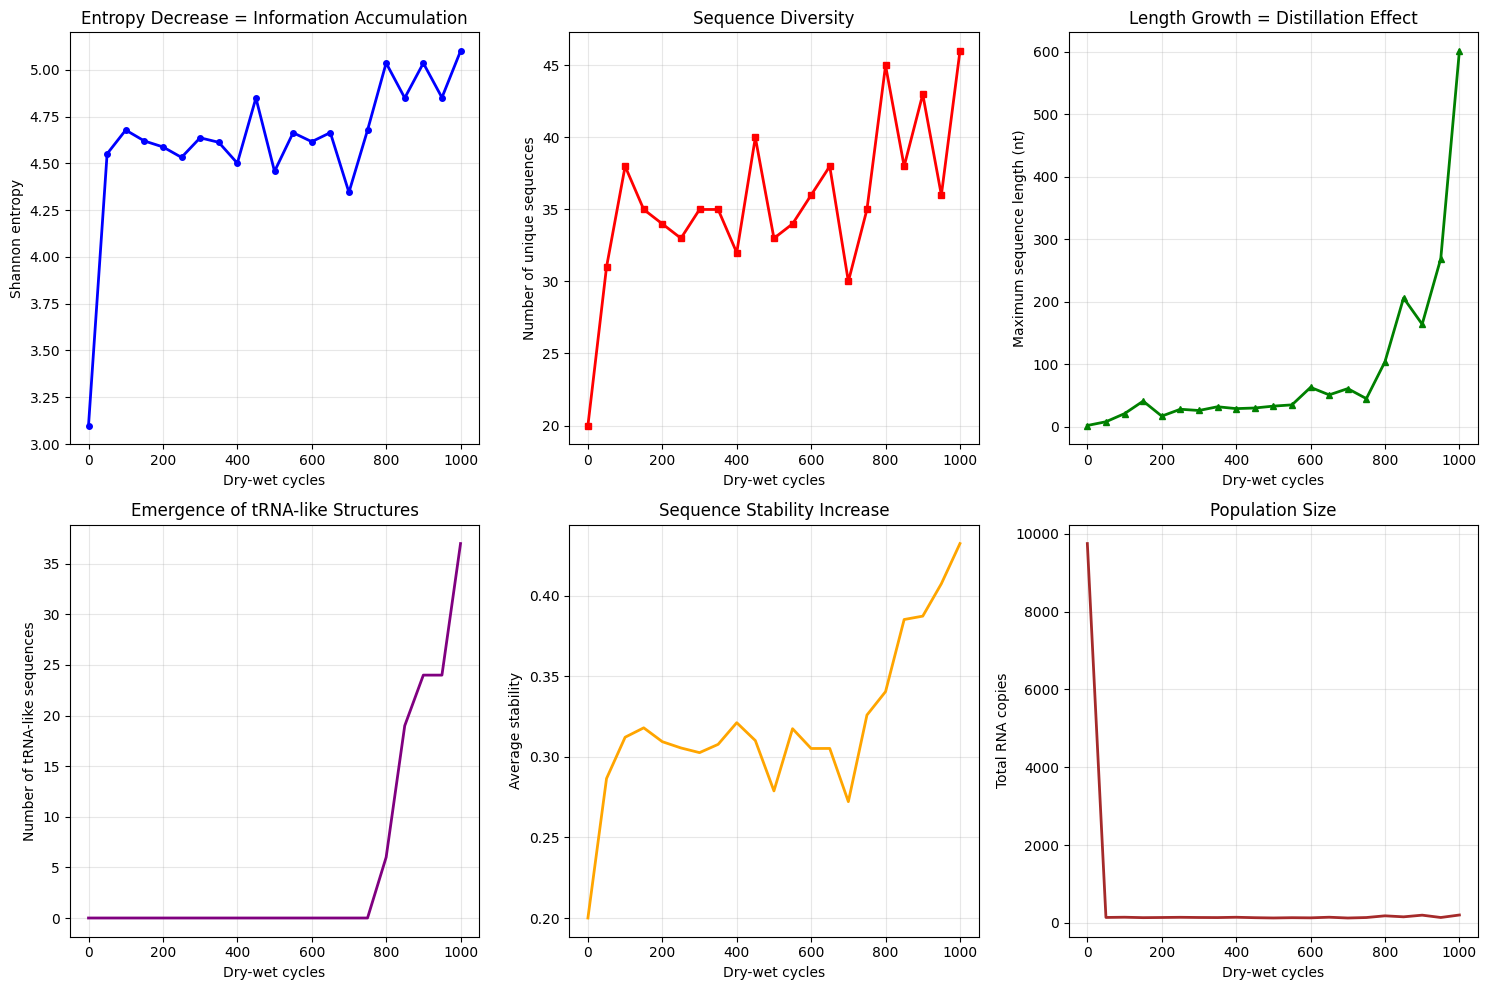


STAGE 1 COMPLETE

Converged RNA pool saved to: converged_rna_pool.json
This file can be used as the environmental RNA pool for Stage 2.


In [5]:
# ============================================================================
# Part 5: Main Program
# ============================================================================

if __name__ == "__main__":
    # ================================================================
    # STAGE 1: RNA STABILITY DISTILLATION PARAMETERS
    # ================================================================
    #
    # All parameters from the original simulation are preserved here.
    # The simulation starts from monomers (A, U, G, C) and builds up.
    #
    # ================================================================

    # --- USER CONFIGURABLE PARAMETERS (Same as original) ---
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 10000          # Total monomers at start
    NUM_CYCLES = 1000                        # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.001         # 1% of initial pool per cycle
    LIGATION_PROB = 0.15                     # Base ligation probability
    HARSHNESS = 0.15                         # Environmental harshness
    TRNA_MIN_STEM_LOOPS = 4                  # Minimum stem-loops for tRNA detection
    TRNA_MIN_END_PAIRS = 4                   # Minimum end pairs for acceptor stem
    TRNA_USE_VIENNA = True                  # Use ViennaRNA for tRNA validation
    MAX_SEQ_LENGTH = 1000                     # Maximum sequence length
    DRY_GROWTH_FACTOR = 1.3                  # Growth factor during dry phase
    WET_DEGRADATION_STRENGTH = 0.15           # Degradation intensity
    OUTPUT_FILE = 'converged_rna_pool.json'  # Output file for Stage 2
    # ----------------------------

    # Create and run Stage 1 simulation
    stage1 = RNAStabilityDistillation(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        harshness=HARSHNESS,
        trna_min_stem_loops=TRNA_MIN_STEM_LOOPS,
        trna_min_end_pairs=TRNA_MIN_END_PAIRS,
        trna_use_vienna=TRNA_USE_VIENNA,
        max_seq_length=MAX_SEQ_LENGTH,
        dry_growth_factor=DRY_GROWTH_FACTOR,
        wet_degradation_strength=WET_DEGRADATION_STRENGTH,
        output_file=OUTPUT_FILE
    )

    # Run the simulation
    stage1.run()

    # Plot results
    stage1.plot_results()

    print("\n" + "=" * 80)
    print("STAGE 1 COMPLETE")
    print("=" * 80)
    print(f"\nConverged RNA pool saved to: {OUTPUT_FILE}")
    print("This file can be used as the environmental RNA pool for Stage 2.")

In [6]:
# clear_memory
def clear_memory_between_stages():
    """clear_memory"""
    import gc

    for name in dir():
        obj = globals().get(name)
        if obj is not None and hasattr(obj, '__sizeof__'):
            if obj.__sizeof__() > 1e6:  #
                print(f"  Deleting {name} ({obj.__sizeof__()//1024} KB)")
                del globals()[name]
    gc.collect()
    print("  Memory cleared between stages")

clear_memory_between_stages()

  Memory cleared between stages


**Simulation Logic Description**

**Overview**

This simulation implements Stage 2 of the Stability-Distillation Hypothesis, modeling the transition from an RNA world to a DNA-based cellular system with primitive viral vectors. The simulation runs in a two-pool system where Pool A (upstream) continuously supplies stable RNA sequences and lipids to Pool B (downstream), where cellular evolution occurs.

**Key Mechanisms**

1. **Synergistic Translation Tag System (Genetic Code Origin)**

Ten random RNA sequences (4 nucleotides each) serve as translation tags—analogous to ribosome binding sites (RBS/Shine-Dalgarno) and start codons.


2. **Lipid-Limited Cell Division**

Cell division requires two simultaneous conditions:

Sufficient macromolecules (RNA + DNA + protein mass) for cellular content

Sufficient lipids for membrane formation

When lipids are insufficient, cells cannot divide. They continue accumulating macromolecules, leading to increased osmotic pressure. If macromolecules exceed the osmotic rupture threshold, the cell ruptures—releasing its contents (including DNA) into the environment.

This mechanism naturally produces:

Normal division: When resources are abundant

Rupture: When lipid shortage prevents division, causing lethal accumulation

3. **Primitive Vectors (Proto-Viruses)**

When DNA cells rupture, they release free DNA into the environment. These free DNA molecules—called primitive vectors—can be encapsulated by lipid vesicles during dry phases, forming new DNA cells. The encapsulation probability increases with free DNA concentration, creating positive feedback: more DNA cells → more rupture → more vectors → more DNA cells.

This models the origin of horizontal gene transfer and primitive viral particles.


**Two-Pool System**

**Pool A (Upstream):**

High temperature, strong wet-dry cycles

Abiotic synthesis of RNA and lipids

RNA stability distillation enriches stable sequences

Supplies RNA, lipids, and primitive cells to Pool B

**Pool B (Downstream):**

Moderate temperature, weaker wet-dry cycles

Cellular evolution, DNA emergence, primitive vector propagation

Contains the cell population and environmental RNA/lipids

**Expected Results**

**Scenario 1**: RNA-Only Dominance (Early Stage)
Most cells contain 0-1 translation tags

Translation efficiency extremely low (0.1× - 1×)

Slow growth, low division rate

High dependence on environmental RNA from Pool A

**Scenario 2**: DNA Cell Emergence
Reverse transcription captures multi-tag RNAs into DNA

DNA cells produce abundant high-tag RNAs via transcription

Translation efficiency reaches 100× - 1000×

DNA cells grow and divide much faster

**Scenario 3**: Lipid-Limited Dynamics
As DNA cells proliferate, lipid consumption increases

Lipids become limiting → division slows

Cells accumulate macromolecules while waiting to divide

Accumulation triggers osmotic rupture when threshold exceeded

**Scenario 4**: Primitive Vector Propagation
Ruptured DNA cells release free DNA vectors

Vectors encapsulate to form new DNA cells

Positive feedback drives DNA cell population growth

Vector concentration correlates with DNA cell density



**Summary**

This simulation demonstrates that DNA emergence is not merely about information storage stability, but about capturing and preserving synergistic regulatory elements (multiple translation tags). The lipid-limited division mechanism naturally produces viral-like spread of genetic material, showing that viruses are not parasites that evolved later, but an intrinsic property of primitive genetic systems—where fast replication inevitably leads to resource exhaustion, rupture, and horizontal transfer.



In [18]:
print("hi")

hi


✓ ViennaRNA loaded successfully
STAGE 2: DNA Emergence with Protein-Dependent Replication

Key Features:
  • DNA replication rate depends on protein synthesis
  • Cell division requires sufficient protein
  • Dual-tag system: Normal tags (10x/20x/30x) + Special tags (30x/100x/1000x)
  • DNA-RNA similarity tracking confirms reverse transcription
  • Multi-cell encapsulation based on lipid availability

  Normal tags: 10 tags (length 4)
  Special tags: 10 tags (length 8)
  Loaded Pool A: 37 sequences
  Initialized 30 RNA-ONLY cells
STAGE 2: DNA Emergence with Protein-Dependent Replication

Initialization: 30 RNA-ONLY cells
  • 95% random sequences
  • 5% stable sequences from Pool A

Protein-Dependent DNA Replication:
  • Base rate: 1.02
  • Protein factor: 0.1
  • Protein division threshold: 100.0

Dual-Tag Translation System:
  • Normal tags (10): 10x/20x/30x for 2/4/6+ tags
  • Special tags (10): 30x/100x/1000x for 1/2/3+ tags

Multi-Cell Encapsulation:
  • New cells = lipids × 20%




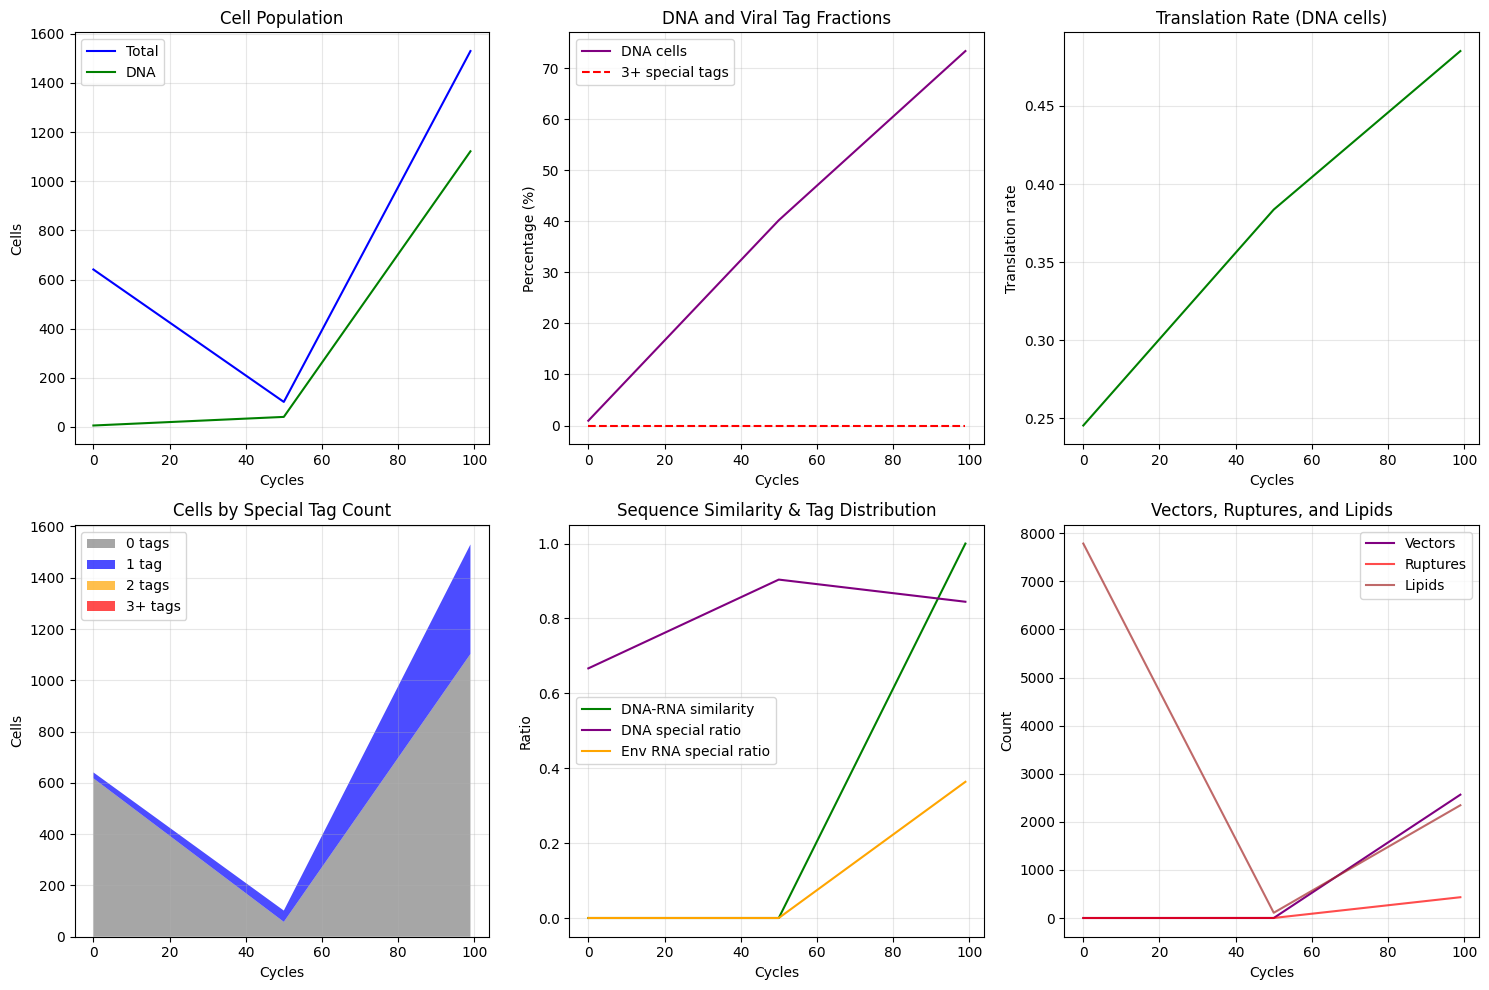


Stage 2 Summary
Total cells: 1530
DNA cells: 1122 (73.3%)
Cells with 3+ special tags (viral): 0 (0.0%)
DNA special tag ratio: 84.5%
DNA-RNA sequence similarity: 1.00
Primitive vectors: 2564
Extinctions: 0
Rupture events: 432
Fusion events: 7027
New cells formed: 6906
Final translation (DNA): 1.775024

  ✓ High DNA-RNA similarity detected!
    This confirms reverse transcription is faithfully
    capturing environmental RNA sequences.

  ~ DNA cells reached majority

SIMULATION COMPLETE


In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
STAGE 2: DNA Emergence with Dual-Tag System, Protein-Dependent Replication, and Sequence Similarity Analysis
================================================================================
SIMULATION LOGIC DESCRIPTION
================================================================================

This simulation implements a two-pool system where DNA emerges naturally from
RNA-only cells through reverse transcription, with a dual-tag system for
translation regulation and protein-dependent DNA replication.

KEY MECHANISMS:

1. PROTEIN-DEPENDENT DNA REPLICATION:
   - DNA replication rate depends on protein synthesis rate
   - No protein → No DNA replication → No cell division
   - This creates real natural selection for functional genes

2. PROTEIN-DEPENDENT CELL DIVISION:
   - Division requires sufficient protein mass (not just total macromolecules)
   - Cells cannot divide without functional translation system

3. DUAL-TAG TRANSLATION SYSTEM:
   - Normal tags (10 tags): 2 tags=10x, 4 tags=20x, 6+ tags=30x
   - Special tags (10 tags): 1 tag=30x, 2 tags=100x, 3+ tags=1000x

4. SEQUENCE SIMILARITY ANALYSIS:
   - DNA-RNA similarity (T↔U mapping) shows reverse transcription fidelity
   - Special tag distribution in DNA vs environmental RNA
   - Tracks horizontal gene transfer

5. MULTI-CELL ENCAPSULATION:
   - New cells based on lipid availability

================================================================================
"""

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
import json
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")

# ============================================================================
# Part 1: Stability Calculation Functions
# ============================================================================

USE_VIENNA_GLOBAL = False
HARSHNESS_GLOBAL = 1.0

def calculate_stability_vienna(sequence, harshness=1.0):
    if len(sequence) < 4:
        return 0.2, "", 0
    try:
        fc = RNA.fold_compound(sequence)
        (ss, mfe) = fc.mfe()
        raw_stability = -mfe / 50.0
        stability = min(0.95, max(0.05, raw_stability))
        if harshness != 1.0:
            deviation = stability - 0.5
            stability = 0.5 + deviation * harshness
            stability = min(0.95, max(0.05, stability))
        return stability, ss, mfe
    except:
        return calculate_stability_heuristic(sequence, harshness), "", 0

def calculate_stability_heuristic(sequence, harshness=1.0):
    if len(sequence) < 4:
        return 0.2
    comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}
    half_len = len(sequence) // 2
    complement_score = 0
    if half_len >= 1:
        first_half = sequence[:half_len]
        second_half_rev = sequence[half_len:][::-1]
        matches = 0
        for i in range(min(len(first_half), len(second_half_rev))):
            if comp_map.get(first_half[i], '') == second_half_rev[i]:
                matches += 1
        complement_score = matches / max(1, half_len)
    structural_score = 0
    for i in range(len(sequence) - 3):
        for length in range(3, min(8, (len(sequence) - i) // 2)):
            left = sequence[i:i+length]
            right = sequence[i+length:i+2*length][::-1]
            if len(right) >= length:
                matches = 0
                for k in range(length):
                    if comp_map.get(left[k], '') == right[k]:
                        matches += 1
                pair_rate = matches / length
                if pair_rate > structural_score:
                    structural_score = pair_rate
    gc_ratio = (sequence.count('G') + sequence.count('C')) / len(sequence)
    stability = 0.1 + 0.5 * complement_score + 0.3 * structural_score + 0.1 * gc_ratio
    if len(sequence) > 30 and structural_score > 0.5:
        stability = min(0.95, stability + 0.1)
    if harshness != 1.0:
        deviation = stability - 0.5
        stability = 0.5 + deviation * harshness
        stability = min(0.95, max(0.05, stability))
    return stability

def get_stability(sequence):
    if USE_VIENNA_GLOBAL and VIENNA_AVAILABLE and len(sequence) >= 4:
        stability, _, _ = calculate_stability_vienna(sequence, HARSHNESS_GLOBAL)
        return stability
    else:
        return calculate_stability_heuristic(sequence, HARSHNESS_GLOBAL)


# ============================================================================
# Part 2: Dual-Tag Translation System
# ============================================================================

MIN_TRANSLATION_LENGTH = 20

# Normal tags (10 tags, length 4) - for cellular optimization
NUM_NORMAL_TAGS = 10
NORMAL_TAG_LENGTH = 4
NORMAL_TAG_BOOST_2 = 10.0
NORMAL_TAG_BOOST_4 = 20.0
NORMAL_TAG_BOOST_6 = 30.0

# Special tags (10 tags, length 8) - viral/high-efficiency elements
NUM_SPECIAL_TAGS = 10
SPECIAL_TAG_LENGTH = 8
SPECIAL_TAG_BOOST_1 = 30.0
SPECIAL_TAG_BOOST_2 = 100.0
SPECIAL_TAG_BOOST_3 = 1000.0

NORMAL_TAGS = []
SPECIAL_TAGS = []

def initialize_tags(seed=None):
    """Initialize normal and special translation tags."""
    global NORMAL_TAGS, SPECIAL_TAGS
    if seed is not None:
        random.seed(seed)

    nucleotides = ['A', 'U', 'G', 'C']

    # Generate normal tags (length 4)
    NORMAL_TAGS = []
    for _ in range(NUM_NORMAL_TAGS):
        tag = ''.join(random.choice(nucleotides) for _ in range(NORMAL_TAG_LENGTH))
        NORMAL_TAGS.append(tag)

    # Generate special tags (length 8)
    SPECIAL_TAGS = []
    for _ in range(NUM_SPECIAL_TAGS):
        tag = ''.join(random.choice(nucleotides) for _ in range(SPECIAL_TAG_LENGTH))
        SPECIAL_TAGS.append(tag)

    print(f"  Normal tags: {NUM_NORMAL_TAGS} tags (length {NORMAL_TAG_LENGTH})")
    print(f"  Special tags: {NUM_SPECIAL_TAGS} tags (length {SPECIAL_TAG_LENGTH})")

def count_normal_tags(sequence):
    """Count how many normal tags appear in the sequence."""
    count = 0
    for tag in NORMAL_TAGS:
        if tag in sequence:
            count += 1
    return count

def count_special_tags(sequence):
    """Count how many special tags appear in the sequence."""
    count = 0
    for tag in SPECIAL_TAGS:
        if tag in sequence:
            count += 1
    return count

def get_normal_tag_boost(count):
    """Get translation boost from normal tags."""
    if count >= 6:
        return NORMAL_TAG_BOOST_6
    elif count >= 4:
        return NORMAL_TAG_BOOST_4
    elif count >= 2:
        return NORMAL_TAG_BOOST_2
    else:
        return 1.0

def get_special_tag_boost(count):
    """Get translation boost from special tags (viral/high-efficiency)."""
    if count >= 3:
        return SPECIAL_TAG_BOOST_3
    elif count >= 2:
        return SPECIAL_TAG_BOOST_2
    elif count >= 1:
        return SPECIAL_TAG_BOOST_1
    else:
        return 1.0

def get_translation_boost(sequence):
    """Calculate total translation boost from both normal and special tags."""
    special_count = count_special_tags(sequence)
    if special_count >= 3:
        return SPECIAL_TAG_BOOST_3
    elif special_count >= 2:
        return SPECIAL_TAG_BOOST_2
    elif special_count >= 1:
        return SPECIAL_TAG_BOOST_1
    else:
        normal_count = count_normal_tags(sequence)
        return get_normal_tag_boost(normal_count)

def get_translation_efficiency(stability, seq_length, sequence):
    """Calculate translation efficiency based on stability and tags."""
    if seq_length < MIN_TRANSLATION_LENGTH:
        return 0.0

    if stability < 0.2:
        base_efficiency = 0.05
    elif stability < 0.4:
        base_efficiency = 0.2 + (stability - 0.2) * 2.0
    elif stability < 0.7:
        base_efficiency = 0.6 + (stability - 0.4) * 1.0
    elif stability < 0.85:
        base_efficiency = 0.9 - (stability - 0.7) * 2.0
    else:
        base_efficiency = 0.6 - (stability - 0.85) * 2.0

    boost = get_translation_boost(sequence)
    return min(0.95, base_efficiency * boost)

def calculate_translation_rate(rna_distribution, translation_scale_factor=0.3):
    """Calculate protein synthesis rate from RNA distribution."""
    total_efficiency = 0
    total_copies = 0

    for seq, count in rna_distribution.items():
        if len(seq) >= MIN_TRANSLATION_LENGTH:
            stability = get_stability(seq)
            efficiency = get_translation_efficiency(stability, len(seq), seq)
            total_efficiency += efficiency * count
            total_copies += count

    if total_copies == 0:
        return 0.0

    avg_efficiency = total_efficiency / total_copies
    return avg_efficiency * total_copies * translation_scale_factor


# ============================================================================
# Part 3: Sequence Similarity Functions
# ============================================================================

def dna_to_rna(dna_seq):
    """Convert DNA sequence to RNA sequence (T -> U)."""
    return dna_seq.replace('T', 'U')

def calculate_sequence_similarity(seq1, seq2):
    """
    Calculate similarity between two sequences.
    For DNA-RNA comparison, T in DNA matches U in RNA.
    """
    if len(seq1) != len(seq2):
        return 0.0

    matches = 0
    for a, b in zip(seq1, seq2):
        if a == b:
            matches += 1
        elif (a == 'T' and b == 'U') or (a == 'U' and b == 'T'):
            matches += 1
    return matches / len(seq1)

def calculate_dna_rna_similarity(dna_sequences, rna_distribution):
    """
    Calculate the maximum similarity between DNA sequences and environmental RNA.
    """
    if not dna_sequences or not rna_distribution:
        return 0.0

    # Get most common DNA sequence
    dna_counts = defaultdict(int)
    for seq in dna_sequences:
        dna_counts[seq] += 1
    most_common_dna = max(dna_counts.items(), key=lambda x: x[1])[0]

    # Convert DNA to RNA for comparison
    dna_as_rna = dna_to_rna(most_common_dna)

    # Find best matching RNA in environment
    best_similarity = 0.0
    for rna_seq in rna_distribution.keys():
        sim = calculate_sequence_similarity(dna_as_rna, rna_seq)
        if sim > best_similarity:
            best_similarity = sim

    return best_similarity


# ============================================================================
# Part 4: Cell Class
# ============================================================================

class Cell:
    def __init__(self, cell_type='rna_only', dna_sequence=None, dna_copies=1,
                 rna_mass_per_copy=100.0, dna_mass_per_copy=1000.0,
                 protein_mass_per_unit=100.0, cell_size_factor=10.0):
        self.cell_type = cell_type
        self.has_dna = (cell_type == 'dna')
        self.rna_mass_per_copy = rna_mass_per_copy
        self.dna_mass_per_copy = dna_mass_per_copy
        self.protein_mass_per_unit = protein_mass_per_unit
        self.cell_size_factor = cell_size_factor

        if self.has_dna:
            self.dna_sequence = dna_sequence if dna_sequence else []
            self.dna_copies = dna_copies
        else:
            self.dna_sequence = []
            self.dna_copies = 0

        self.rna_distribution = defaultdict(int)
        self.protein_mass = 0.0
        self.amino_acids = 0.0
        self.nucleotides = 0.0
        self.lipid_content = 10.0
        self.size = 0.0
        self.alive = True
        self.generation = 0
        self.division_count = 0
        self.waiting_for_division = False

    def add_rna(self, seq, count=1):
        self.rna_distribution[seq] += count

    def get_total_macromolecules(self):
        rna_mass = sum(self.rna_distribution.values()) * self.rna_mass_per_copy
        dna_mass = self.dna_copies * self.dna_mass_per_copy
        return rna_mass + dna_mass + self.protein_mass

    def get_rna_total_copies(self):
        return sum(self.rna_distribution.values())

    def get_max_special_tags_in_rna(self):
        max_tags = 0
        for seq in self.rna_distribution.keys():
            tags = count_special_tags(seq)
            if tags > max_tags:
                max_tags = tags
        return max_tags

    def get_translation_rate(self):
        return calculate_translation_rate(self.rna_distribution, 0.3)


# ============================================================================
# Part 5: Stage 2 Simulation Class
# ============================================================================

class Stage2Simulation:
    def __init__(self,
                 pool_a_file='converged_rna_pool.json',
                 num_cycles=500,
                 initial_cells=50,
                 max_cells=800,
                 translation_tags=None,
                 pool_a_to_b_transfer_fraction=0.05,
                 lipid_transfer_fraction=0.2,
                 initial_lipids=500.0,
                 lipids_per_new_cell=5.0,
                 lipids_required_for_division=15.0,
                 lipids_released_on_rupture=20.0,
                 lipid_decay_rate=0.05,
                 osmotic_rupture_threshold=2000.0,
                 max_rupture_probability=0.9,
                 division_threshold=1000.0,
                 protein_division_threshold=100.0,
                 cell_fusion_probability=0.08,
                 fusion_dry_phase_boost=2.0,
                 encapsulation_rate=0.8,
                 encapsulation_fraction=0.2,
                 encapsulation_dna_prob_base=0.05,
                 encapsulation_fraction_of_lipids=0.2,
                 # Reverse transcription parameters
                 env_reverse_transcription_rate=0.01,
                 # DNA replication parameters (protein-dependent)
                 dna_replication_base_rate=1.02,
                 dna_replication_protein_factor=0.1,
                 dna_replication_cost=5.0,
                 # Other parameters
                 free_dna_decay_rate=0.1,
                 free_dna_fragmentation_prob=0.5,
                 fragment_min_len=10,
                 fragment_max_len=30,
                 random_rna_ratio=0.95,
                 stable_rna_ratio=0.05,
                 max_absorption_length=50,
                 absorption_rate=30,
                 dna_maintenance_cost=0.01,
                 transcription_rate=0.5,
                 transcription_fraction=0.7,
                 reverse_transcriptase_activity=0.2,
                 rna_inheritance_fraction=0.6,
                 rna_degradation_rate=0.08,
                 translation_scale_factor=0.02,
                 diffusion_coefficient=0.08,
                 env_amino_acid_conc=100.0,
                 env_nucleotide_conc=100.0,
                 rna_mass_per_copy=10.0,
                 dna_mass_per_copy=100.0,
                 protein_mass_per_unit=10.0,
                 nucleotides_per_rna=1.0,
                 nucleotides_per_dna=10.0,
                 cell_size_factor=10.0,
                 initial_amino_acids=50.0,
                 initial_nucleotides=50.0,
                 dna_initial_amino_acids=100.0,
                 dna_initial_nucleotides=100.0):

        self.num_cycles = num_cycles
        self.max_cells = max_cells
        self.cycle = 0

        # RNA initialization ratios
        self.random_rna_ratio = random_rna_ratio
        self.stable_rna_ratio = stable_rna_ratio

        # Reverse transcription parameters
        self.env_reverse_transcription_rate = env_reverse_transcription_rate

        # DNA replication parameters (protein-dependent)
        self.dna_replication_base_rate = dna_replication_base_rate
        self.dna_replication_protein_factor = dna_replication_protein_factor
        self.dna_replication_cost = dna_replication_cost

        # Division parameters
        self.protein_division_threshold = protein_division_threshold

        # Translation tags
        global NORMAL_TAGS, SPECIAL_TAGS
        if translation_tags is not None:
            NORMAL_TAGS, SPECIAL_TAGS = translation_tags
        elif len(NORMAL_TAGS) == 0:
            initialize_tags()

        # Pool transfer parameters
        self.pool_a_to_b_transfer_fraction = pool_a_to_b_transfer_fraction
        self.lipid_transfer_fraction = lipid_transfer_fraction

        # Lipid parameters
        self.initial_lipids = initial_lipids
        self.lipids_per_new_cell = lipids_per_new_cell
        self.lipids_required_for_division = lipids_required_for_division
        self.lipids_released_on_rupture = lipids_released_on_rupture
        self.lipid_decay_rate = lipid_decay_rate

        # Osmotic rupture parameters
        self.osmotic_rupture_threshold = osmotic_rupture_threshold
        self.max_rupture_probability = max_rupture_probability
        self.division_threshold = division_threshold

        # Cell fusion parameters
        self.cell_fusion_probability = cell_fusion_probability
        self.fusion_dry_phase_boost = fusion_dry_phase_boost

        # Encapsulation parameters
        self.encapsulation_rate = encapsulation_rate
        self.encapsulation_dna_prob_base = encapsulation_dna_prob_base
        self.encapsulation_fraction = encapsulation_fraction
        self.encapsulation_fraction_of_lipids = encapsulation_fraction_of_lipids

        # Primitive vector degradation parameters
        self.free_dna_decay_rate = free_dna_decay_rate
        self.free_dna_fragmentation_prob = free_dna_fragmentation_prob
        self.fragment_min_len = fragment_min_len
        self.fragment_max_len = fragment_max_len

        # Absorption parameters
        self.max_absorption_length = max_absorption_length
        self.absorption_rate = absorption_rate

        # DNA parameters
        self.dna_maintenance_cost = dna_maintenance_cost
        self.transcription_rate = transcription_rate
        self.transcription_fraction = transcription_fraction
        self.reverse_transcriptase_activity = reverse_transcriptase_activity

        # RNA parameters
        self.rna_inheritance_fraction = rna_inheritance_fraction
        self.rna_degradation_rate = rna_degradation_rate
        self.translation_scale_factor = translation_scale_factor

        # Environment parameters
        self.diffusion_coefficient = diffusion_coefficient
        self.env_amino_acid_conc = env_amino_acid_conc
        self.env_nucleotide_conc = env_nucleotide_conc

        # Mass constants
        self.rna_mass_per_copy = rna_mass_per_copy
        self.dna_mass_per_copy = dna_mass_per_copy
        self.protein_mass_per_unit = protein_mass_per_unit
        self.nucleotides_per_rna = nucleotides_per_rna
        self.nucleotides_per_dna = nucleotides_per_dna
        self.cell_size_factor = cell_size_factor

        # Initial resources
        self.initial_amino_acids = initial_amino_acids
        self.initial_nucleotides = initial_nucleotides
        self.dna_initial_amino_acids = dna_initial_amino_acids
        self.dna_initial_nucleotides = dna_initial_nucleotides

        global USE_VIENNA_GLOBAL
        USE_VIENNA_GLOBAL = False

        # Load Pool A
        self.pool_a_rna = self._load_pool_a(pool_a_file)
        self.pool_a_total_copies = sum(self.pool_a_rna.values())

        # Pool B state
        self.cells = []
        self.pool_b_environmental_rna = defaultdict(int)
        self.pool_b_lipids = initial_lipids
        self.pool_b_free_dna = []

        self._initialize_cells(initial_cells)

        # Statistics
        self.history = {
            'cycle': [], 'total_cells': [], 'dna_cells': [], 'rna_cells': [],
            'avg_dna_copies': [], 'avg_rna_copies': [],
            'avg_translation_rate_rna': [], 'avg_translation_rate_dna': [],
            'avg_size': [], 'total_lipids': [],
            'pool_a_total_rna': [], 'pool_b_env_rna_total': [],
            'rupture_events': [], 'fusion_events': [], 'new_cells_formed': [],
            'primitive_vectors': [],
            'cells_with_0_special': [], 'cells_with_1_special': [],
            'cells_with_2_special': [], 'cells_with_3plus_special': [],
            'dna_special_ratio': [], 'env_rna_special_ratio': [],
            'dna_rna_similarity': [], 'avg_protein_mass': [],
            'total_extinction_events': 0
        }

        self.rupture_counter = 0
        self.fusion_counter = 0
        self.new_cells_counter = 0
        self.extinction_counter = 0
        self.vector_counter = 0

        print("=" * 80)
        print("STAGE 2: DNA Emergence with Protein-Dependent Replication")
        print("=" * 80)
        print(f"\nInitialization: {initial_cells} RNA-ONLY cells")
        print(f"  • {random_rna_ratio*100:.0f}% random sequences")
        print(f"  • {stable_rna_ratio*100:.0f}% stable sequences from Pool A")
        print(f"\nProtein-Dependent DNA Replication:")
        print(f"  • Base rate: {dna_replication_base_rate}")
        print(f"  • Protein factor: {dna_replication_protein_factor}")
        print(f"  • Protein division threshold: {protein_division_threshold}")
        print(f"\nDual-Tag Translation System:")
        print(f"  • Normal tags ({NUM_NORMAL_TAGS}): 10x/20x/30x for 2/4/6+ tags")
        print(f"  • Special tags ({NUM_SPECIAL_TAGS}): 30x/100x/1000x for 1/2/3+ tags")
        print(f"\nMulti-Cell Encapsulation:")
        print(f"  • New cells = lipids × {encapsulation_fraction_of_lipids*100:.0f}%")
        print()

    def _load_pool_a(self, filepath):
        sequences = defaultdict(int)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
                for item in data.get('sequences', []):
                    if isinstance(item, list) and len(item) >= 2:
                        seq = item[0].upper()
                        count = item[1]
                    elif isinstance(item, str):
                        seq = item.upper()
                        count = 1
                    else:
                        continue
                    if all(c in 'AUCG' for c in seq) and len(seq) >= 4:
                        sequences[seq] += count
            print(f"  Loaded Pool A: {len(sequences)} sequences")
            return sequences
        except:
            pass

        txt_file = filepath.replace('.json', '.txt')
        try:
            with open(txt_file, 'r') as f:
                for line in f:
                    parts = line.strip().split(',')
                    seq = parts[0].upper()
                    count = int(parts[1]) if len(parts) > 1 else 1
                    if all(c in 'AUCG' for c in seq) and len(seq) >= 4:
                        sequences[seq] += count
            print(f"  Loaded Pool A from TXT: {len(sequences)} sequences")
            return sequences
        except:
            pass

        print("  Using default Pool A")
        default_seqs = ['GCGCGCGC', 'CGCGCGCG', 'GGCCGGCC', 'CGAAUUCG', 'AUUCGAAU']
        for seq in default_seqs:
            sequences[seq] = 100
        return sequences

    def _initialize_cells(self, num_cells):
        """Initialize ONLY RNA cells (no DNA cells initially)."""
        self.cells = []
        nucleotides = ['A', 'U', 'G', 'C']
        pool_a_keys = list(self.pool_a_rna.keys())

        for _ in range(num_cells):
            cell = Cell(cell_type='rna_only',
                       rna_mass_per_copy=self.rna_mass_per_copy,
                       dna_mass_per_copy=self.dna_mass_per_copy,
                       protein_mass_per_unit=self.protein_mass_per_unit,
                       cell_size_factor=self.cell_size_factor)

            num_rna_types = random.randint(5, 15)
            num_random = int(num_rna_types * self.random_rna_ratio)
            num_stable = num_rna_types - num_random

            if num_stable == 0 and num_rna_types > 0 and pool_a_keys:
                num_stable = 1
                num_random = num_rna_types - 1

            selected_seqs = []

            for _ in range(num_random):
                length = random.randint(6, 15)
                seq = ''.join(random.choice(nucleotides) for _ in range(length))
                selected_seqs.append(seq)

            if pool_a_keys and num_stable > 0:
                stable_samples = random.sample(pool_a_keys, min(num_stable, len(pool_a_keys)))
                selected_seqs.extend(stable_samples)

            for seq in selected_seqs:
                count = random.randint(5, 20)
                cell.add_rna(seq, count)

            cell.amino_acids = self.initial_amino_acids
            cell.nucleotides = self.initial_nucleotides
            cell.lipid_content = 10.0
            cell.size = cell.get_total_macromolecules() / self.cell_size_factor
            self.cells.append(cell)

        print(f"  Initialized {num_cells} RNA-ONLY cells")

    def _reset_environment(self):
        self.pool_b_environmental_rna = defaultdict(int)
        self.pool_b_free_dna = []
        self.pool_b_lipids = self.initial_lipids

    def _transfer_from_pool_a(self):
        for seq, count in self.pool_a_rna.items():
            transfer = int(count * self.pool_a_to_b_transfer_fraction)
            if transfer > 0:
                self.pool_b_environmental_rna[seq] += transfer

        lipid_transfer = self.lipid_transfer_fraction * 100
        self.pool_b_lipids += lipid_transfer

    def _decay_free_dna(self):
        new_free_dna = []
        for dna_seq in self.pool_b_free_dna:
            if random.random() < self.free_dna_decay_rate:
                if random.random() < self.free_dna_fragmentation_prob:
                    if len(dna_seq) > self.fragment_min_len:
                        frag_len = random.randint(self.fragment_min_len,
                                                  min(self.fragment_max_len, len(dna_seq)))
                        start = random.randint(0, len(dna_seq) - frag_len)
                        fragment = dna_seq[start:start+frag_len]
                        new_free_dna.append(fragment)
            else:
                new_free_dna.append(dna_seq)
        self.pool_b_free_dna = new_free_dna

    def _get_dna_encapsulation_probability(self):
        num_free_dna = len(self.pool_b_free_dna)
        return min(0.5, self.encapsulation_dna_prob_base + num_free_dna / 200.0)

    def _encapsulate_rna_into_cell(self, cell):
        env_rna_items = list(self.pool_b_environmental_rna.items())
        if not env_rna_items:
            return

        num_types = random.randint(5, 15)
        num_types = min(num_types, len(env_rna_items))
        sampled = random.sample(env_rna_items, num_types)

        for seq, env_count in sampled:
            captured = max(1, int(env_count * self.encapsulation_fraction))
            cell.add_rna(seq, captured)
            self.pool_b_environmental_rna[seq] -= captured
            if self.pool_b_environmental_rna[seq] <= 0:
                del self.pool_b_environmental_rna[seq]

    def _create_one_cell(self):
        dna_encapsulation_prob = self._get_dna_encapsulation_probability()
        has_dna_in_env = len(self.pool_b_free_dna) > 0

        if has_dna_in_env and random.random() < dna_encapsulation_prob:
            dna_sequence = [random.choice(self.pool_b_free_dna)]
            new_cell = Cell(cell_type='dna', dna_sequence=dna_sequence, dna_copies=1,
                           rna_mass_per_copy=self.rna_mass_per_copy,
                           dna_mass_per_copy=self.dna_mass_per_copy,
                           protein_mass_per_unit=self.protein_mass_per_unit,
                           cell_size_factor=self.cell_size_factor)
            self.pool_b_free_dna.remove(dna_sequence[0])
            self.vector_counter += 1
        else:
            new_cell = Cell(cell_type='rna_only',
                           rna_mass_per_copy=self.rna_mass_per_copy,
                           dna_mass_per_copy=self.dna_mass_per_copy,
                           protein_mass_per_unit=self.protein_mass_per_unit,
                           cell_size_factor=self.cell_size_factor)

        self._encapsulate_rna_into_cell(new_cell)

        new_cell.amino_acids = self.initial_amino_acids
        new_cell.nucleotides = self.initial_nucleotides
        new_cell.lipid_content = self.lipids_per_new_cell
        new_cell.size = new_cell.get_total_macromolecules() / self.cell_size_factor

        return new_cell

    def _encapsulate_new_cells(self, is_dry_phase):
        if not is_dry_phase:
            return 0

        # Calculate capacity considering both lipids and max cells
        max_by_lipids = int(self.pool_b_lipids / self.lipids_per_new_cell)
        max_by_capacity = self.max_cells - len(self.cells)
        max_possible = min(max_by_lipids, max_by_capacity)

        target_new = int(max_possible * self.encapsulation_fraction_of_lipids)

        if target_new <= 0:
            return 0

        new_count = 0
        for _ in range(target_new):
            if random.random() > self.encapsulation_rate:
                continue

            if self.pool_b_lipids < self.lipids_per_new_cell:
                break

            if len(self.cells) >= self.max_cells:
                break

            new_cell = self._create_one_cell()
            if new_cell:
                self.cells.append(new_cell)
                self.pool_b_lipids -= self.lipids_per_new_cell
                new_count += 1

        self.new_cells_counter += new_count
        return new_count

    def _absorb_environmental_rna(self, cell):
        env_items = list(self.pool_b_environmental_rna.items())
        absorbed = 0
        for seq, count in env_items:
            if absorbed >= self.absorption_rate:
                break
            uptake = min(count, self.absorption_rate - absorbed)
            if uptake > 0:
                cell.add_rna(seq, uptake)
                self.pool_b_environmental_rna[seq] -= uptake
                if self.pool_b_environmental_rna[seq] <= 0:
                    del self.pool_b_environmental_rna[seq]
                absorbed += uptake

    def _free_diffusion_uptake(self, cell):
        gradient_aa = self.env_amino_acid_conc - cell.amino_acids
        if gradient_aa > 0:
            cell.amino_acids += self.diffusion_coefficient * gradient_aa
        gradient_nt = self.env_nucleotide_conc - cell.nucleotides
        if gradient_nt > 0:
            cell.nucleotides += self.diffusion_coefficient * gradient_nt

    def _dna_maintenance(self, cell):
        if not cell.has_dna or cell.dna_copies == 0:
            return
        cost = cell.dna_copies * self.dna_maintenance_cost
        if cell.nucleotides >= cost:
            cell.nucleotides -= cost
        else:
            ratio = 1.0 - (cell.nucleotides / cost) if cost > 0 else 1.0
            cell.dna_copies *= (1.0 - ratio * 0.5)
            cell.nucleotides = 0

    def _dna_replication(self, cell):
        """
        DNA replication rate depends on protein synthesis.
        Without protein, DNA cannot replicate.
        """
        if not cell.has_dna or cell.dna_copies == 0:
            return

        # Calculate translation efficiency (protein synthesis rate)
        translation_rate = calculate_translation_rate(cell.rna_distribution,
                                                       self.translation_scale_factor)

        # Protein-dependent replication factor
        # More protein = faster DNA replication
        replication_factor = min(1.0, translation_rate * self.dna_replication_protein_factor)

        # Effective replication rate
        effective_rate = 1.0 + (self.dna_replication_base_rate - 1.0) * replication_factor

        new = cell.dna_copies * (effective_rate - 1.0)
        nucleotides_needed = new * self.dna_replication_cost

        if cell.nucleotides >= nucleotides_needed:
            cell.dna_copies += new
            cell.nucleotides -= nucleotides_needed
        else:
            possible = cell.nucleotides / self.dna_replication_cost if self.dna_replication_cost > 0 else 0
            cell.dna_copies += possible
            cell.nucleotides = 0

    def _transcription(self, cell):
        if not cell.has_dna or cell.dna_copies == 0 or len(cell.dna_sequence) == 0:
            return
        transcribable = [seq for seq in cell.dna_sequence
                         if random.random() < self.transcription_fraction]
        if not transcribable:
            return
        total_rna = cell.dna_copies * self.transcription_rate
        rna_per_gene = total_rna / len(transcribable)
        needed = total_rna * self.nucleotides_per_rna
        if cell.nucleotides >= needed:
            for seq in transcribable:
                cell.add_rna(seq, rna_per_gene)
            cell.nucleotides -= needed
        else:
            possible = cell.nucleotides / self.nucleotides_per_rna if self.nucleotides_per_rna > 0 else 0
            for seq in transcribable:
                cell.add_rna(seq, possible / len(transcribable))
            cell.nucleotides = 0

    def _reverse_transcription(self, cell):
        """Reverse transcription: RNA to DNA."""
        candidates = []

        # From intracellular RNA
        for seq, count in cell.rna_distribution.items():
            if len(seq) >= MIN_TRANSLATION_LENGTH:
                candidates.append(seq)

        # Attempt intracellular reverse transcription
        for seq in set(candidates):
            eff = self.reverse_transcriptase_activity
            eff *= (0.5 + get_stability(seq) * 0.5)

            if random.random() < eff:
                if not cell.has_dna:
                    cell.dna_sequence = [seq]
                    cell.dna_copies = 1
                    cell.cell_type = 'dna'
                    cell.has_dna = True
                    cell.amino_acids += self.dna_initial_amino_acids
                    cell.nucleotides += self.dna_initial_nucleotides
                else:
                    if seq not in cell.dna_sequence:
                        cell.dna_sequence.append(seq)
                        cell.dna_copies += 0.1

        # From environmental RNA (lower efficiency)
        env_candidates = []
        for seq, count in self.pool_b_environmental_rna.items():
            if len(seq) >= MIN_TRANSLATION_LENGTH:
                env_candidates.append(seq)

        for seq in set(env_candidates):
            eff = self.env_reverse_transcription_rate
            eff *= (0.5 + get_stability(seq) * 0.5)

            if random.random() < eff and seq not in cell.dna_sequence:
                if not cell.has_dna:
                    cell.dna_sequence = [seq]
                    cell.dna_copies = 1
                    cell.cell_type = 'dna'
                    cell.has_dna = True
                    cell.amino_acids += self.dna_initial_amino_acids
                    cell.nucleotides += self.dna_initial_nucleotides
                else:
                    if seq not in cell.dna_sequence:
                        cell.dna_sequence.append(seq)
                        cell.dna_copies += 0.1

    def _translation(self, cell):
        translation_rate = calculate_translation_rate(cell.rna_distribution,
                                                       self.translation_scale_factor)
        protein = min(translation_rate, cell.amino_acids)
        if protein > 0:
            cell.protein_mass += protein * self.protein_mass_per_unit
            cell.amino_acids -= protein
        return translation_rate

    def _rna_degradation(self, cell):
        for seq, count in list(cell.rna_distribution.items()):
            stability = get_stability(seq)
            deg_prob = (1 - stability) * self.rna_degradation_rate
            count_int = int(count)
            remaining = np.random.binomial(count_int, 1.0 - deg_prob)
            degraded = count_int - remaining

            if remaining > 0:
                cell.rna_distribution[seq] = remaining
            else:
                del cell.rna_distribution[seq]

            if degraded > 0 and len(seq) > 10:
                frag_len = min(10, max(2, len(seq) // 3))
                fragment = seq[:frag_len]
                self.pool_b_environmental_rna[fragment] += degraded

    def _cell_growth(self, cell):
        cell.size = cell.get_total_macromolecules() / self.cell_size_factor

    def _check_division_or_rupture(self, cell):
        macromolecules = cell.get_total_macromolecules()
        protein_mass = cell.protein_mass

        if macromolecules >= self.division_threshold:
            # Division requires sufficient protein as well
            if cell.lipid_content >= self.lipids_required_for_division and protein_mass >= self.protein_division_threshold:
                cell.lipid_content -= self.lipids_required_for_division
                # Reset protein mass after division (consumed)
                cell.protein_mass /= 2
                return 'divide'
            else:
                cell.waiting_for_division = True
                if macromolecules >= self.osmotic_rupture_threshold:
                    rupture_prob = min(self.max_rupture_probability,
                                      (macromolecules - self.osmotic_rupture_threshold) / self.osmotic_rupture_threshold)
                    if random.random() < rupture_prob:
                        return 'rupture'
                return 'wait'
        return 'grow'

    def _rupture_cell(self, cell):
        for seq, count in cell.rna_distribution.items():
            self.pool_b_environmental_rna[seq] += int(count)

        if cell.has_dna and cell.dna_sequence:
            for seq in cell.dna_sequence:
                self.pool_b_free_dna.append(seq)

        self.pool_b_lipids += self.lipids_released_on_rupture
        self.rupture_counter += 1
        cell.alive = False

    def _divide_rna_cell(self, mother):
        d1 = Cell(cell_type='rna_only',
                 rna_mass_per_copy=self.rna_mass_per_copy,
                 dna_mass_per_copy=self.dna_mass_per_copy,
                 protein_mass_per_unit=self.protein_mass_per_unit,
                 cell_size_factor=self.cell_size_factor)
        d2 = Cell(cell_type='rna_only',
                 rna_mass_per_copy=self.rna_mass_per_copy,
                 dna_mass_per_copy=self.dna_mass_per_copy,
                 protein_mass_per_unit=self.protein_mass_per_unit,
                 cell_size_factor=self.cell_size_factor)

        for seq, count in mother.rna_distribution.items():
            count_int = int(count)
            split = np.random.binomial(count_int, 0.5)
            if split > 0:
                d1.add_rna(seq, split)
            if count_int - split > 0:
                d2.add_rna(seq, count_int - split)

        d1.amino_acids = mother.amino_acids / 2
        d2.amino_acids = mother.amino_acids / 2
        d1.nucleotides = mother.nucleotides / 2
        d2.nucleotides = mother.nucleotides / 2
        d1.protein_mass = mother.protein_mass / 2
        d2.protein_mass = mother.protein_mass / 2
        d1.lipid_content = mother.lipid_content / 2
        d2.lipid_content = mother.lipid_content / 2
        d1.size = d1.get_total_macromolecules() / self.cell_size_factor
        d2.size = d2.get_total_macromolecules() / self.cell_size_factor
        return d1, d2

    def _divide_dna_cell(self, mother):
        d1 = Cell(cell_type='dna', dna_sequence=mother.dna_sequence.copy(),
                  dna_copies=mother.dna_copies / 2,
                  rna_mass_per_copy=self.rna_mass_per_copy,
                  dna_mass_per_copy=self.dna_mass_per_copy,
                  protein_mass_per_unit=self.protein_mass_per_unit,
                  cell_size_factor=self.cell_size_factor)
        d2 = Cell(cell_type='dna', dna_sequence=mother.dna_sequence.copy(),
                  dna_copies=mother.dna_copies / 2,
                  rna_mass_per_copy=self.rna_mass_per_copy,
                  dna_mass_per_copy=self.dna_mass_per_copy,
                  protein_mass_per_unit=self.protein_mass_per_unit,
                  cell_size_factor=self.cell_size_factor)

        transcribed = False
        for seq in d1.dna_sequence:
            if random.random() < self.transcription_fraction:
                rna_count = d1.dna_copies * self.transcription_rate / max(1, len(d1.dna_sequence))
                d1.add_rna(seq, rna_count)
                d2.add_rna(seq, rna_count)
                transcribed = True
        if not transcribed and d1.dna_sequence:
            rna_count = d1.dna_copies * self.transcription_rate / max(1, len(d1.dna_sequence))
            d1.add_rna(d1.dna_sequence[0], rna_count)
            d2.add_rna(d2.dna_sequence[0], rna_count)

        for seq, count in mother.rna_distribution.items():
            count_int = int(count)
            inherited = int(count_int * self.rna_inheritance_fraction)
            if inherited > 0:
                d1.add_rna(seq, inherited)
                d2.add_rna(seq, inherited)

        d1.amino_acids = mother.amino_acids / 2
        d2.amino_acids = mother.amino_acids / 2
        d1.nucleotides = mother.nucleotides / 2
        d2.nucleotides = mother.nucleotides / 2
        d1.protein_mass = mother.protein_mass / 2
        d2.protein_mass = mother.protein_mass / 2
        d1.lipid_content = mother.lipid_content / 2
        d2.lipid_content = mother.lipid_content / 2
        d1.size = d1.get_total_macromolecules() / self.cell_size_factor
        d2.size = d2.get_total_macromolecules() / self.cell_size_factor
        return d1, d2

    def _cell_fusion(self, cell1, cell2, is_dry_phase):
        fusion_prob = self.cell_fusion_probability
        if is_dry_phase:
            fusion_prob *= self.fusion_dry_phase_boost
        lipid_factor = min(2.0, (cell1.lipid_content + cell2.lipid_content) / 20.0)
        fusion_prob *= lipid_factor

        if random.random() < fusion_prob:
            self.fusion_counter += 1
            return self._perform_fusion(cell1, cell2)
        return None

    def _perform_fusion(self, cell1, cell2):
        fused = Cell(cell_type='dna' if (cell1.has_dna or cell2.has_dna) else 'rna_only',
                    rna_mass_per_copy=self.rna_mass_per_copy,
                    dna_mass_per_copy=self.dna_mass_per_copy,
                    protein_mass_per_unit=self.protein_mass_per_unit,
                    cell_size_factor=self.cell_size_factor)

        for seq, count in cell1.rna_distribution.items():
            fused.add_rna(seq, count)
        for seq, count in cell2.rna_distribution.items():
            fused.add_rna(seq, count)

        if cell1.has_dna:
            for seq in cell1.dna_sequence:
                if seq not in fused.dna_sequence:
                    fused.dna_sequence.append(seq)
        if cell2.has_dna:
            for seq in cell2.dna_sequence:
                if seq not in fused.dna_sequence:
                    fused.dna_sequence.append(seq)
        fused.dna_copies = (cell1.dna_copies + cell2.dna_copies) / 2

        fused.amino_acids = cell1.amino_acids + cell2.amino_acids
        fused.nucleotides = cell1.nucleotides + cell2.nucleotides
        fused.protein_mass = cell1.protein_mass + cell2.protein_mass
        fused.lipid_content = cell1.lipid_content + cell2.lipid_content
        fused.size = (cell1.size + cell2.size) / 2
        fused.generation = max(cell1.generation, cell2.generation) + 1

        return fused

    def step(self):
        """Execute one complete dry-wet cycle."""

        # ========== DRY PHASE ==========
        is_dry = True

        self._transfer_from_pool_a()
        self._encapsulate_new_cells(is_dry_phase=True)

        # Cell fusion during dry phase
        if len(self.cells) > 1:
            new_cells_after_fusion = []
            i = 0
            while i < len(self.cells):
                if i + 1 < len(self.cells):
                    fused = self._cell_fusion(self.cells[i], self.cells[i+1], is_dry_phase=True)
                    if fused:
                        new_cells_after_fusion.append(fused)
                        i += 2
                        continue
                new_cells_after_fusion.append(self.cells[i])
                i += 1
            self.cells = new_cells_after_fusion

        # Process all cells
        trans_rna_list = []
        trans_dna_list = []

        for cell in self.cells:
            if cell.alive:
                self._absorb_environmental_rna(cell)
                self._free_diffusion_uptake(cell)
                self._dna_maintenance(cell)
                self._dna_replication(cell)
                self._reverse_transcription(cell)
                self._transcription(cell)
                trans_rate = self._translation(cell)

                if cell.cell_type == 'rna_only':
                    trans_rna_list.append(trans_rate)
                else:
                    trans_dna_list.append(trans_rate)

                self._rna_degradation(cell)
                self._cell_growth(cell)

        # ========== WET PHASE ==========
        is_dry = False

        new_cells_list = []
        for cell in self.cells:
            if not cell.alive:
                continue

            action = self._check_division_or_rupture(cell)

            if action == 'rupture':
                self._rupture_cell(cell)
                continue
            elif action == 'divide':
                if cell.cell_type == 'rna_only':
                    d1, d2 = self._divide_rna_cell(cell)
                else:
                    d1, d2 = self._divide_dna_cell(cell)
                if len(new_cells_list) + 2 <= self.max_cells:
                    new_cells_list.extend([d1, d2])
                else:
                    new_cells_list.append(cell)
            elif action == 'wait':
                new_cells_list.append(cell)
            else:
                new_cells_list.append(cell)

        self.cells = new_cells_list

        # Cell fusion during wet phase
        if len(self.cells) > 1:
            new_cells_after_fusion = []
            i = 0
            while i < len(self.cells):
                if i + 1 < len(self.cells):
                    fused = self._cell_fusion(self.cells[i], self.cells[i+1], is_dry_phase=False)
                    if fused:
                        new_cells_after_fusion.append(fused)
                        i += 2
                        continue
                new_cells_after_fusion.append(self.cells[i])
                i += 1
            self.cells = new_cells_after_fusion

        # Decay processes
        self.pool_b_lipids *= (1.0 - self.lipid_decay_rate)

        for seq in list(self.pool_b_environmental_rna.keys()):
            self.pool_b_environmental_rna[seq] *= 0.7
            if self.pool_b_environmental_rna[seq] < 1:
                del self.pool_b_environmental_rna[seq]

        self._decay_free_dna()

        # Check for extinction
        if len(self.cells) == 0:
            self.extinction_counter += 1
            self.history['total_extinction_events'] = self.extinction_counter
            self._reset_environment()
            self._initialize_cells(30)
            print(f"  Extinction #{self.extinction_counter}: Population and environment reset")

        avg_trans_rna = np.mean(trans_rna_list) if trans_rna_list else 0.0
        avg_trans_dna = np.mean(trans_dna_list) if trans_dna_list else 0.0

        self.history['avg_translation_rate_rna'].append(avg_trans_rna)
        self.history['avg_translation_rate_dna'].append(avg_trans_dna)

        self.cycle += 1

    def run(self):
        print(f"\nStarting Stage 2: {self.num_cycles} cycles...")
        print("-" * 70)
        for cycle in range(self.num_cycles):
            self.step()
            if cycle % 50 == 0 or cycle == self.num_cycles - 1:
                self._record_statistics(cycle)
        print("-" * 70)
        print("Stage 2 complete!")

    def _record_statistics(self, cycle):
        if not self.cells:
            return

        total = len(self.cells)
        dna = sum(1 for c in self.cells if c.has_dna)
        rna = total - dna
        avg_dna = np.mean([c.dna_copies for c in self.cells if c.has_dna]) if dna > 0 else 0
        avg_rna = np.mean([c.get_rna_total_copies() for c in self.cells])
        avg_size = np.mean([c.size for c in self.cells])
        avg_protein = np.mean([c.protein_mass for c in self.cells])
        avg_trans_rna = self.history['avg_translation_rate_rna'][-1] if self.history['avg_translation_rate_rna'] else 0
        avg_trans_dna = self.history['avg_translation_rate_dna'][-1] if self.history['avg_translation_rate_dna'] else 0

        # Categorize cells by special tag count
        special_0 = special_1 = special_2 = special_3plus = 0
        all_dna_sequences = []

        for cell in self.cells:
            max_special = cell.get_max_special_tags_in_rna()
            if max_special == 0:
                special_0 += 1
            elif max_special == 1:
                special_1 += 1
            elif max_special == 2:
                special_2 += 1
            else:
                special_3plus += 1

            if cell.has_dna:
                all_dna_sequences.extend(cell.dna_sequence)

        # Calculate DNA special tag ratio
        dna_special = 0
        for dna_seq in all_dna_sequences:
            if count_special_tags(dna_seq) > 0:
                dna_special += 1
        dna_special_ratio = dna_special / len(all_dna_sequences) if all_dna_sequences else 0

        # Calculate environmental RNA special tag ratio
        env_rna_special = 0
        total_env_rna = 0
        for rna_seq, count in self.pool_b_environmental_rna.items():
            if count_special_tags(rna_seq) > 0:
                env_rna_special += count
            total_env_rna += count
        env_rna_special_ratio = env_rna_special / total_env_rna if total_env_rna > 0 else 0

        # Calculate DNA-RNA similarity
        dna_rna_sim = calculate_dna_rna_similarity(all_dna_sequences, self.pool_b_environmental_rna)

        num_free_dna = len(self.pool_b_free_dna)

        self.history['cycle'].append(cycle)
        self.history['total_cells'].append(total)
        self.history['dna_cells'].append(dna)
        self.history['rna_cells'].append(rna)
        self.history['avg_dna_copies'].append(avg_dna)
        self.history['avg_rna_copies'].append(avg_rna)
        self.history['avg_size'].append(avg_size)
        self.history['total_lipids'].append(self.pool_b_lipids)
        self.history['pool_a_total_rna'].append(self.pool_a_total_copies)
        self.history['pool_b_env_rna_total'].append(total_env_rna)
        self.history['rupture_events'].append(self.rupture_counter)
        self.history['fusion_events'].append(self.fusion_counter)
        self.history['new_cells_formed'].append(self.new_cells_counter)
        self.history['primitive_vectors'].append(num_free_dna)
        self.history['cells_with_0_special'].append(special_0)
        self.history['cells_with_1_special'].append(special_1)
        self.history['cells_with_2_special'].append(special_2)
        self.history['cells_with_3plus_special'].append(special_3plus)
        self.history['dna_special_ratio'].append(dna_special_ratio)
        self.history['env_rna_special_ratio'].append(env_rna_special_ratio)
        self.history['dna_rna_similarity'].append(dna_rna_sim)
        self.history['avg_protein_mass'].append(avg_protein)

        dna_pct = dna / total * 100 if total > 0 else 0

        print(f"Cycle {cycle:4d}: Cells={total:3d} | DNA={dna:2d} ({dna_pct:.1f}%) | "
              f"Special:0={special_0:2d} 1={special_1:2d} 2={special_2:2d} 3+={special_3plus:2d} | "
              f"DNA-Spec={dna_special_ratio:.1%} | Env-Spec={env_rna_special_ratio:.1%} | "
              f"Sim={dna_rna_sim:.2f} | Vectors={num_free_dna:3d} | Rupt={self.rupture_counter}")

    def plot_results(self):
        if not self.history.get('cycle'):
            print("No data to plot")
            return

        min_len = len(self.history['cycle'])
        for key in self.history:
            if isinstance(self.history[key], list) and len(self.history[key]) < min_len:
                min_len = len(self.history[key])

        if min_len < 2:
            print(f"Not enough data (min_len={min_len})")
            return

        cycles = self.history['cycle'][:min_len]
        total_cells = self.history['total_cells'][:min_len]
        dna_cells = self.history['dna_cells'][:min_len]
        dna_pct = [d/t*100 if t>0 else 0 for d,t in zip(dna_cells, total_cells)]
        trans_dna = self.history['avg_translation_rate_dna'][:min_len]

        special_0 = self.history['cells_with_0_special'][:min_len]
        special_1 = self.history['cells_with_1_special'][:min_len]
        special_2 = self.history['cells_with_2_special'][:min_len]
        special_3plus = self.history['cells_with_3plus_special'][:min_len]

        dna_special = self.history['dna_special_ratio'][:min_len]
        env_special = self.history['env_rna_special_ratio'][:min_len]
        dna_rna_sim = self.history['dna_rna_similarity'][:min_len]
        vectors = self.history['primitive_vectors'][:min_len]
        lipids = self.history['total_lipids'][:min_len]

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Plot 1: Cell population
        axes[0,0].plot(cycles, total_cells, 'b-', label='Total')
        axes[0,0].plot(cycles, dna_cells, 'g-', label='DNA')
        axes[0,0].set_xlabel('Cycles')
        axes[0,0].set_ylabel('Cells')
        axes[0,0].set_title('Cell Population')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Plot 2: DNA fraction and special tag fractions
        axes[0,1].plot(cycles, dna_pct, 'purple', label='DNA cells')
        axes[0,1].plot(cycles, [s/t*100 if t>0 else 0 for s,t in zip(special_3plus, total_cells)],
                      'red', label='3+ special tags', linestyle='--')
        axes[0,1].set_xlabel('Cycles')
        axes[0,1].set_ylabel('Percentage (%)')
        axes[0,1].set_title('DNA and Viral Tag Fractions')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # Plot 3: Translation rate (DNA cells)
        axes[0,2].plot(cycles, trans_dna, 'g-')
        axes[0,2].set_xlabel('Cycles')
        axes[0,2].set_ylabel('Translation rate')
        axes[0,2].set_title('Translation Rate (DNA cells)')
        axes[0,2].grid(True, alpha=0.3)

        # Plot 4: Special tag distribution (stacked)
        axes[1,0].stackplot(cycles, special_0, special_1, special_2, special_3plus,
                           labels=['0 tags', '1 tag', '2 tags', '3+ tags'],
                           colors=['gray', 'blue', 'orange', 'red'], alpha=0.7)
        axes[1,0].set_xlabel('Cycles')
        axes[1,0].set_ylabel('Cells')
        axes[1,0].set_title('Cells by Special Tag Count')
        axes[1,0].legend(loc='upper left')
        axes[1,0].grid(True, alpha=0.3)

        # Plot 5: DNA-RNA similarity and special tag ratios
        axes[1,1].plot(cycles, dna_rna_sim, 'green', label='DNA-RNA similarity')
        axes[1,1].plot(cycles, dna_special, 'purple', label='DNA special ratio')
        axes[1,1].plot(cycles, env_special, 'orange', label='Env RNA special ratio')
        axes[1,1].set_xlabel('Cycles')
        axes[1,1].set_ylabel('Ratio')
        axes[1,1].set_title('Sequence Similarity & Tag Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

        # Plot 6: Vectors, ruptures, and lipids
        axes[1,2].plot(cycles, vectors, 'purple', label='Vectors')
        axes[1,2].plot(cycles, self.history['rupture_events'][:min_len], 'red', label='Ruptures', alpha=0.7)
        axes[1,2].plot(cycles, lipids, 'brown', label='Lipids', alpha=0.7)
        axes[1,2].set_xlabel('Cycles')
        axes[1,2].set_ylabel('Count')
        axes[1,2].set_title('Vectors, Ruptures, and Lipids')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('stage2_results.png', dpi=150)
        plt.show()

    def print_summary(self):
        print("\n" + "=" * 80)
        print("Stage 2 Summary")
        print("=" * 80)
        if not self.history.get('total_cells'):
            print("  No data")
            return

        final = self.history['total_cells'][-1] if self.history['total_cells'] else 0
        dna = self.history['dna_cells'][-1] if self.history['dna_cells'] else 0
        special_3plus = self.history['cells_with_3plus_special'][-1] if self.history['cells_with_3plus_special'] else 0
        vectors = self.history['primitive_vectors'][-1] if self.history['primitive_vectors'] else 0
        dna_special = self.history['dna_special_ratio'][-1] if self.history['dna_special_ratio'] else 0
        dna_rna_sim = self.history['dna_rna_similarity'][-1] if self.history['dna_rna_similarity'] else 0
        pct = dna/final*100 if final>0 else 0
        virus_pct = special_3plus/final*100 if final>0 else 0

        print(f"Total cells: {final}")
        print(f"DNA cells: {dna} ({pct:.1f}%)")
        print(f"Cells with 3+ special tags (viral): {special_3plus} ({virus_pct:.1f}%)")
        print(f"DNA special tag ratio: {dna_special:.1%}")
        print(f"DNA-RNA sequence similarity: {dna_rna_sim:.2f}")
        print(f"Primitive vectors: {vectors}")
        print(f"Extinctions: {self.history['total_extinction_events']}")
        print(f"Rupture events: {self.rupture_counter}")
        print(f"Fusion events: {self.fusion_counter}")
        print(f"New cells formed: {self.new_cells_counter}")

        if self.history['avg_translation_rate_dna']:
            print(f"Final translation (DNA): {self.history['avg_translation_rate_dna'][-1]:.6f}")

        if dna_rna_sim > 0.7:
            print("\n  ✓ High DNA-RNA similarity detected!")
            print("    This confirms reverse transcription is faithfully")
            print("    capturing environmental RNA sequences.")

        if pct > 80:
            print("\n  ✓ DNA cells dominated!")
        elif pct > 50:
            print("\n  ~ DNA cells reached majority")
        else:
            print("\n  ⚠ RNA-only still dominant")


# ============================================================================
# Part 6: Main Program
# ============================================================================

if __name__ == "__main__":
    print("=" * 80)
    print("STAGE 2: DNA Emergence with Protein-Dependent Replication")
    print("=" * 80)
    print("\nKey Features:")
    print("  • DNA replication rate depends on protein synthesis")
    print("  • Cell division requires sufficient protein")
    print("  • Dual-tag system: Normal tags (10x/20x/30x) + Special tags (30x/100x/1000x)")
    print("  • DNA-RNA similarity tracking confirms reverse transcription")
    print("  • Multi-cell encapsulation based on lipid availability")
    print()

    random.seed(42)
    initialize_tags()

    sim = Stage2Simulation(
        pool_a_file='converged_rna_pool.json',
        num_cycles=100,
        initial_cells=30,
        max_cells=10000,
        pool_a_to_b_transfer_fraction=0.1,
        lipid_transfer_fraction=0.3,
        initial_lipids=10000.0,
        lipids_per_new_cell=3.0,
        lipids_required_for_division=5.0,
        lipids_released_on_rupture=30.0,
        lipid_decay_rate=0.03,
        osmotic_rupture_threshold=8000.0,
        max_rupture_probability=0.3,
        division_threshold=5000.0,
        protein_division_threshold=100.0,
        cell_fusion_probability=0.08,
        fusion_dry_phase_boost=2.0,
        encapsulation_rate=1.0,
        encapsulation_fraction=0.7,
        encapsulation_dna_prob_base=0.05,
        encapsulation_fraction_of_lipids=0.2,
        env_reverse_transcription_rate=0.01,
        dna_replication_base_rate=1.02,
        dna_replication_protein_factor=0.1,
        dna_replication_cost=5.0,
        free_dna_decay_rate=0.1,
        free_dna_fragmentation_prob=0.5,
        fragment_min_len=10,
        fragment_max_len=30,
        random_rna_ratio=0.95,
        stable_rna_ratio=0.05,
        max_absorption_length=50,
        absorption_rate=30,
        dna_maintenance_cost=0.01,
        transcription_rate=0.5,
        transcription_fraction=0.7,
        reverse_transcriptase_activity=0.2,
        rna_inheritance_fraction=0.6,
        rna_degradation_rate=0.08,
        translation_scale_factor=0.02,
        diffusion_coefficient=0.08,
        env_amino_acid_conc=100.0,
        env_nucleotide_conc=100.0,
        rna_mass_per_copy=10.0,
        dna_mass_per_copy=100.0,
        protein_mass_per_unit=10.0,
        nucleotides_per_rna=1.0,
        nucleotides_per_dna=10.0,
        cell_size_factor=10.0,
        initial_amino_acids=50.0,
        initial_nucleotides=50.0,
        dna_initial_amino_acids=100.0,
        dna_initial_nucleotides=100.0
    )

    sim.run()
    sim.plot_results()
    sim.print_summary()

    print("\n" + "=" * 80)
    print("SIMULATION COMPLETE")
    print("=" * 80)